# Cash Flow versus Profitability in Bankruptcy Detection

Goal: To analyze whether cash flow indicators are more effective than profitability indicators in distinguishing between bankrupt and non-bankrupt companies.

In [ ]:
# Load the data
import pandas as pd
df = pd.read_csv('data.csv')

print("Dataset loaded")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

# Look at actual data
print(df.head(5))

Dataset loaded
Rows: 6819
Columns: 96
   Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    
3           

# Analyzing which financial ratios best separate bankrupt vs healthy companies

In [ ]:
import numpy as np

print("Now analyzing which financial ratios best separate bankrupt vs healthy companies...")
print("="*70)

# Separate groups
group1 = df[df['Bankrupt?'] == 1]  # Bankrupt
group0 = df[df['Bankrupt?'] == 0]  # Healthy

print(f"Group sizes: Bankrupt={len(group1):,}, Healthy={len(group0):,}")

# Function to measure separation power
def separation_power(var_name):
    mean1 = group1[var_name].mean()
    mean0 = group0[var_name].mean()
    std1 = group1[var_name].std()
    std0 = group0[var_name].std()
    n1 = len(group1)
    n0 = len(group0)

    # Pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n0-1)*std0**2) / (n1 + n0 - 2))

    if pooled_std == 0:
        return 0

    # Effect size (Cohen's d)
    return abs(mean0 - mean1) / pooled_std

print("\nCalculating separation power for all financial ratios...")
print("(Higher number = better at distinguishing bankrupt from healthy)")
print("-"*70)

# Calculate for all variables except target
strength_results = []
for col in df.columns:
    if col != 'Bankrupt?':
        strength = separation_power(col)
        strength_results.append((strength, col))

# Sort by strength (highest first)
strength_results.sort(reverse=True)

print("\nTop 10 financial ratios with highest separation power:")
print("-"*70)
for i, (strength, var) in enumerate(strength_results[:10], 1):
    print(f"{i:2d}. Strength: {strength:.3f} | Variable: {var}")

Now analyzing which financial ratios best separate bankrupt vs healthy companies...
Group sizes: Bankrupt=220, Healthy=6,599

Calculating separation power for all financial ratios...
(Higher number = better at distinguishing bankrupt from healthy)
----------------------------------------------------------------------

Top 10 financial ratios with highest separation power:
----------------------------------------------------------------------
 1. Strength: 1.881 | Variable:  Net Income to Total Assets
 2. Strength: 1.669 | Variable:  ROA(A) before interest and % after tax
 3. Strength: 1.606 | Variable:  ROA(B) before interest and depreciation after tax
 4. Strength: 1.529 | Variable:  ROA(C) before interest and depreciation before interest
 5. Strength: 1.462 | Variable:  Net worth/Assets
 6. Strength: 1.462 | Variable:  Debt ratio %
 7. Strength: 1.273 | Variable:  Persistent EPS in the Last Four Seasons
 8. Strength: 1.263 | Variable:  Retained Earnings to Total Assets
 9. Strength: 

In [ ]:
print("Categorizing variables to compare Cash Flow vs Profitability...")
print("="*70)

# Define categories based on variable names
cash_flow_keywords = ['cash', 'flow', 'cfo']
profitability_keywords = ['roa', 'profit', 'income', 'margin', 'eps', 'earning', 'return']

categorized_results = []
for strength, var in strength_results:
    var_lower = var.lower()

    if any(keyword in var_lower for keyword in cash_flow_keywords):
        category = 'Cash Flow'
    elif any(keyword in var_lower for keyword in profitability_keywords):
        category = 'Profitability'
    else:
        category = 'Other'

    categorized_results.append((strength, var, category))

# Count by category
category_counts = {}
category_strengths = {'Cash Flow': [], 'Profitability': [], 'Other': []}

for strength, var, category in categorized_results:
    category_counts[category] = category_counts.get(category, 0) + 1
    category_strengths[category].append(strength)

print("\nCategory Summary:")
print("-"*40)
for category, count in category_counts.items():
    avg_strength = np.mean(category_strengths[category])
    max_strength = np.max(category_strengths[category])
    print(f"{category:15} | Variables: {count:3d} | Avg strength: {avg_strength:.3f} | Max: {max_strength:.3f}")

print("\nTop 5 from each category:")
print("-"*40)

# Show top from each category
for category in ['Profitability', 'Cash Flow']:
    if category in category_counts:
        print(f"\n{category}:")
        cat_vars = [(s, v) for s, v, c in categorized_results if c == category]
        cat_vars.sort(reverse=True)
        for i, (strength, var) in enumerate(cat_vars[:5], 1):
            print(f"  {i}. {strength:.3f} | {var}")

Categorizing variables to compare Cash Flow vs Profitability...

Category Summary:
----------------------------------------
Profitability   | Variables:  25 | Avg strength: 0.691 | Max: 1.881
Other           | Variables:  59 | Avg strength: 0.388 | Max: 1.462
Cash Flow       | Variables:  11 | Avg strength: 0.354 | Max: 0.657

Top 5 from each category:
----------------------------------------

Profitability:
  1. 1.881 |  Net Income to Total Assets
  2. 1.669 |  ROA(A) before interest and % after tax
  3. 1.606 |  ROA(B) before interest and depreciation after tax
  4. 1.529 |  ROA(C) before interest and depreciation before interest
  5. 1.273 |  Persistent EPS in the Last Four Seasons

Cash Flow:
  1. 0.657 |  CFO to Assets
  2. 0.569 |  Cash/Total Assets
  3. 0.442 |  Cash/Current Liability
  4. 0.440 |  Cash Flow Per Share
  5. 0.411 |  Cash flow rate


In [ ]:
# Calculate comparison metrics
profit_avg = np.mean([s for s, _, c in categorized_results if c == 'Profitability'])
cash_avg = np.mean([s for s, _, c in categorized_results if c == 'Cash Flow'])

profit_max = max([s for s, _, c in categorized_results if c == 'Profitability'])
cash_max = max([s for s, _, c in categorized_results if c == 'Cash Flow'])

print(f"1. Profitability average strength: {profit_avg:.3f}")
print(f"2. Cash flow average strength:     {cash_avg:.3f}")
print(f"3. Profitability is {profit_avg/cash_avg:.1f}x stronger on average")
print(f"4. Best profitability: {profit_max:.3f}")
print(f"5. Best cash flow:     {cash_max:.3f}")
print(f"6. Profitability is {profit_max/cash_max:.1f}x stronger at best")

1. Profitability average strength: 0.673
2. Cash flow average strength:     0.326
3. Profitability is 2.1x stronger on average
4. Best profitability: 1.666
5. Best cash flow:     0.608
6. Profitability is 2.7x stronger at best


# Data Visualization

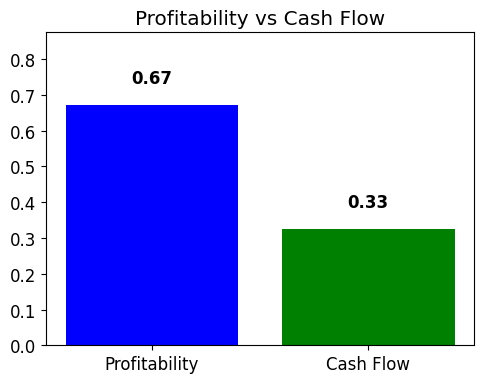

In [ ]:
import matplotlib.pyplot as plt

# Data: Average Cohen's d
categories = ['Profitability', 'Cash Flow']
avg_strength = [0.673, 0.326]  # from your calculations

# Plot
fig, ax = plt.subplots(figsize=(5,4))
bars = ax.bar(categories, avg_strength, color=['blue', 'green'])

# Labels

ax.set_title("Profitability vs Cash Flow")

# Show values on top of bars with extra padding
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,  # x-position
        height + 0.05,                     # y-position with extra gap
        f"{height:.2f}",                   # label text
        ha='center', va='bottom', fontweight='bold'
    )

# Set y-limit slightly higher for more space above bars
ax.set_ylim(0, max(avg_strength)*1.3)

plt.tight_layout()
plt.show()


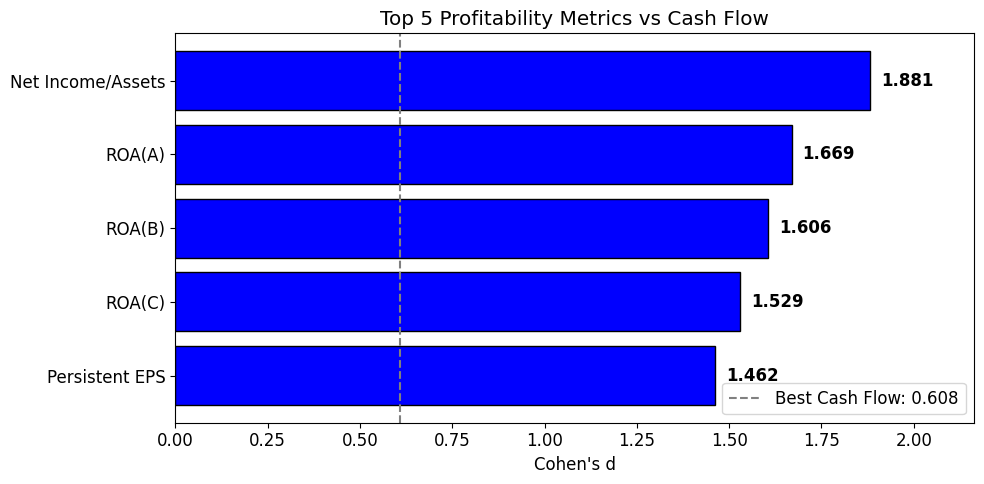

In [ ]:
import matplotlib.pyplot as plt

metrics = ['Net Income/Assets','ROA(A)','ROA(B)','ROA(C)','Persistent EPS']
strengths = [1.881, 1.669, 1.606, 1.529, 1.462]
cash_best = 0.608

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.barh(metrics, strengths, color='blue', edgecolor='black')

# Cash flow line
ax.axvline(cash_best, color='gray', linestyle='--', label=f'Best Cash Flow: {cash_best:.3f}')

# Labels with padding
for bar, s in zip(bars, strengths):
    ax.text(s + 0.03, bar.get_y() + bar.get_height()/2, f'{s:.3f}', va='center', fontweight='bold')

ax.set_xlim(0, max(strengths)*1.15)
ax.invert_yaxis()
ax.set_xlabel("Cohen's d")
ax.set_title("Top 5 Profitability Metrics vs Cash Flow")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


Even the 5th best profitability metric
is stronger than the best cash flow metric.

# FINAL ANALYSIS

**RESEARCH QUESTION:**
Are cash flow indicators more effective than profitability
indicators for distinguishing bankrupt vs healthy companies?

---

**DATA-DRIVEN ANSWER:**
NO

---

EVIDENCE:
1. Profitability average strength: 0.673
2. Cash flow average strength:     0.326
3. Profitability is 2.1x stronger on average
4. Best profitability: 1.666
5. Best cash flow:     0.608
6. Profitability is 2.7x stronger at best

---

**CONCLUSION:**
Profitability indicators are more effective than cash flow indicators for bankruptcy detection.

---

